# PCSM Example/Tutorial
##- Drew E. Winters, PhD.

This workbook serves as a real human data example of applying PCSM.

## Importing PCSM package from GitHub

In [1]:
!git clone https://github.com/drewwint/pcsm

Cloning into 'pcsm'...
remote: Enumerating objects: 91, done.
remote: Counting objects: 100% (91/91), done.
remote: Compressing objects: 100% (74/74), done.
remote: Total 91 (delta 19), reused 74 (delta 11), pack-reused 0 (from 0)
Receiving objects: 100% (91/91), 2.76 MiB | 10.41 MiB/s, done.
Resolving deltas: 100% (19/19), done.


In [2]:
%cd pcsm/code/10_functions/

/content/pcsm/code/10_functions


In [3]:
    import sys
    sys.path.append('/content/pcsm')

In [4]:
!pip install .

Processing /content/pcsm/code/10_functions
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 4.4 MB/s eta 0:00:00
  Created wheel for projlib: filename=projlib-0.1.0-py3-none-any.whl size=66274 sha256=c7df4f82e623bf2c3645fb72638ea9766bea544347adedd7073746fee2307381
  Stored in directory: /tmp/pip-ephem-wheel-cache-10yzflis/wheels/ff/34/8e/280ed67363f202761946191fdc7d0a8d5ed4f5195bac837ce1
Successfully built projlib


In [5]:
import sys
from IPython.utils.io import capture_output

if 'google.colab' in sys.modules:

    with capture_output() as captured:
      ! pip install watermark hmmlearn nilearn

import nilearn
import nilearn.datasets
import nilearn.plotting
import nilearn.image
import nilearn.glm.first_level
from nilearn.glm.first_level import first_level_from_bids
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import watermark
import hmmlearn
from hmmlearn import hmm
import scipy
from scipy.stats import norm, binom, gamma, multivariate_normal
import nibabel as nib
import math
from scipy.stats import gamma
from nilearn.maskers import NiftiLabelsMasker
from sklearn.model_selection import KFold
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist


In [6]:
# To derive PCSM metrics
from projlib import metric_calculation as mc
# for PCSM plotting
from projlib import plotting as pj_plt
# for PCSM alignment of GMMHMM
from projlib import aligning_gmmhmm as alg

## Getting Real Data and Cleaning

### Getting SST Data from OpenNeuro

Selecting participants from the ds00030 dataset on openneuro with SST task data.
- A few participants and done here as an example use.

Data is imported with fetch urls, then filtering of participants for SST, and then extract subjects data.

In [7]:
from nilearn.datasets import (
    fetch_ds000030_urls,
    fetch_openneuro_dataset,
    select_from_index,
)

_, urls = fetch_ds000030_urls()

exclusion_patterns = [
    "*group*",
    "*phenotype*",
    "*mriqc*",
    "*parameter_plots*",
    "*physio_plots*",
    "*space-fsaverage*",
    "*space-T1w*",
    "*dwi*",
    "*beh*",
    "*task-bart*",
    "*task-rest*",
    "*task-scap*",
    "*task-task*",
]


urls = select_from_index(
    urls,
    exclusion_filters=exclusion_patterns,
    n_subjects=3
)

data_dir, _ = fetch_openneuro_dataset(urls=urls)




[fetch_ds000030_urls] Added README.md to /root/nilearn_data

[fetch_ds000030_urls] Dataset created in /root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed

[fetch_ds000030_urls] Downloading data from https://osf.io/86xj7/download ...

[fetch_ds000030_urls]  ...done. (2 seconds, 0 min)

[fetch_openneuro_dataset] Dataset found in /root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed

...

[fetch_openneuro_dataset]  ...done. (0 seconds, 0 min)

[fetch_openneuro_dataset] Downloading data from 
https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/task-pamret_bold.json ...

[fetch_openneuro_dataset]  ...done. (0 seconds, 0 min)

[fetch_openneuro_dataset] Downloading data from 
https://s3.amazonaws.com/openneuro/ds000030/ds000030_R1.0.4/uncompressed/task-stopsignal_bold.json ...

[fetch_openneuro_dataset]  ...done. (0 seconds, 0 min)

In [8]:


task_label = "stopsignal"
space_label = "MNI152NLin2009cAsym"
derivatives_folder = "derivatives/fmriprep"
(
    models,
    models_run_imgs,
    models_events,
    models_confounds,
) = first_level_from_bids(
    data_dir,
    task_label,
    space_label,
    smoothing_fwhm=5.0,
    derivatives_folder=derivatives_folder,
    n_jobs=2,
    verbose=1,
)

/tmp/ipython-input-124387773.py:9: UserWarning: 
No bold.json found in BIDS folder in:
 /root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep.
  ) = first_level_from_bids(
/tmp/ipython-input-124387773.py:9: UserWarning: 'slice_time_ref' not provided and cannot be inferred from metadata.
It will be assumed that the slice timing reference is 0.0 percent of the repetition time.
If it is not the case it will need to be set manually in the generated list of models.
  ) = first_level_from_bids(


[first_level_from_bids] 
Found the following 1 preprocessed BOLD files
- for subject 10159
- for filter: [('task', 'stopsignal'), ('space', 'MNI152NLin2009cAsym')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10159/func/sub-10159_task-stopsig
nal_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

[first_level_from_bids] 
Found the following 1 events files
- for subject 10159
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/sub-10159/func/sub-10159_task-stopsignal_events.tsv

[first_level_from_bids] 
Found the following 1 confounds files
- for subject 10159
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10159/func/sub-10159_task-stopsig
nal_desc-confounds_regressors.tsv

[first_level_from_bids] 
Found the following 1 preprocessed BOLD files
- for subject 10171
- for filter: [('task', 'stopsignal'), ('space', 'MNI152NLin2009cAsym')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10171/func/sub-10171_task-stopsig
nal_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

[first_level_from_bids] 
Found the following 1 events files
- for subject 10171
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/sub-10171/func/sub-10171_task-stopsignal_events.tsv

[first_level_from_bids] 
Found the following 1 confounds files
- for subject 10171
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10171/func/sub-10171_task-stopsig
nal_desc-confounds_regressors.tsv

[first_level_from_bids] 
Found the following 1 preprocessed BOLD files
- for subject 10189
- for filter: [('task', 'stopsignal'), ('space', 'MNI152NLin2009cAsym')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10189/func/sub-10189_task-stopsig
nal_space-MNI152NLin2009cAsym_desc-preproc_bold.nii.gz

[first_level_from_bids] 
Found the following 1 events files
- for subject 10189
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/sub-10189/func/sub-10189_task-stopsignal_events.tsv

[first_level_from_bids] 
Found the following 1 confounds files
- for subject 10189
- for filter: [('task', 'stopsignal')]:
        - 
/root/nilearn_data/ds000030/ds000030_R1.0.4/uncompressed/derivatives/fmriprep/sub-10189/func/sub-10189_task-stopsig
nal_desc-confounds_regressors.tsv

In [9]:

subjects = [f"sub-{models[0].subject_label}",f"sub-{models[1].subject_label}"]
models_confounds[0][0].loc[0,"FramewiseDisplacement"] = 0
models_confounds[1][0].loc[0,"FramewiseDisplacement"] = 0
models_confounds[2][0].loc[0,"FramewiseDisplacement"] = 0

models, imgs, events, confounds = (
    models,
    [models_run_imgs[0][0],models_run_imgs[1][0],models_run_imgs[2][0]],
    [models_events[0][0],models_events[1][0],models_events[2][0]],
    [models_confounds[0][0],models_confounds[1][0],models_confounds[2][0]]
)

### Cleaning the timeseries and Fitting FIR model
We are using minimally preprocessed data so we already have
- alignment
- slice time correction

Here we do additional preprocessing by regressing out
- motion (FD)
- movement on x,y,z plus rotation
- white matter

We need to calculate which frames need censored due to high motion fd > 0.5 and include in our confounds

We fit the FIR model so that we collect values over the timebins to feed into the GMMHMM model


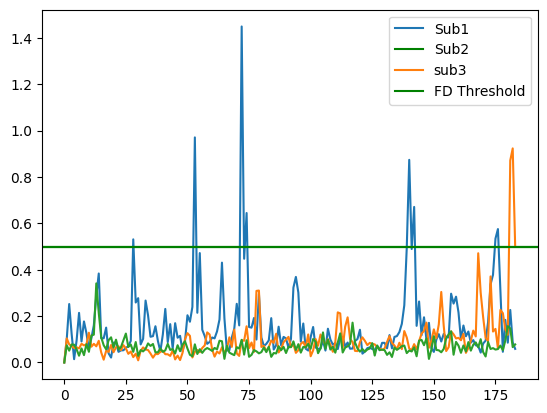

In [10]:
# Getting the frames to censor
f_censor = []
for ii in confounds:
  frames = []
  vec = np.repeat(0,len(ii.FramewiseDisplacement))
  vec[np.array(np.where(ii.loc[:,"FramewiseDisplacement"] > 0.5)[0])] = 1
  frames.append(vec)
  f_censor.append(frames)
  ii.FramewiseDisplacement.plot()
  plt.axhline(y=0.5, color='g', linestyle='-')
  plt.legend(['Sub1','Sub2',"sub3" ,'FD Threshold'])

In [11]:
ind = 0
for ii in confounds:
  ii["censor"] = f_censor[ind][0]
  ind += 1

In [12]:
for ii in range(len(events)):
  events[ii].loc[np.where(events[ii].TrialOutcome == "JUNK")[0], "TrialOutcome"] = "UnsuccessfulGo"



In [13]:

atlas_files = nilearn.datasets.fetch_atlas_schaefer_2018(n_rois = 200, yeo_networks = 17)


[fetch_atlas_schaefer_2018] Dataset created in /root/nilearn_data/schaefer_2018

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_17Networks_order.txt ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

[fetch_atlas_schaefer_2018] Downloading data from 
https://raw.githubusercontent.com/ThomasYeoLab/CBIG/v0.14.3-Update_Yeo2011_Schaefer2018_labelname/stable_projects/b
rain_parcellation/Schaefer2018_LocalGlobal/Parcellations/MNI/Schaefer2018_200Parcels_17Networks_order_FSLMNI152_1mm
.nii.gz ...

[fetch_atlas_schaefer_2018]  ...done. (0 seconds, 0 min)

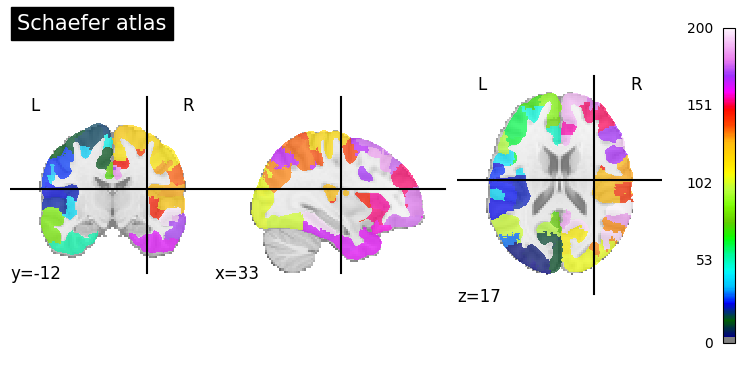

In [14]:
# loading atlas
atlas = nilearn.image.load_img(atlas_files["maps"])
# getting region names
node_names = atlas_files["labels"]
# formatting into a form we can use
# node_names = []
# for label_byte in labels:
#   # Decode the bytes object to a string and then slice it
#   node_names.append(label_byte.decode('utf-8')[2:])

# plotting atlas
nilearn.plotting.plot_roi(atlas, title="Schaefer atlas")

#### Subsetting nodes
While PCSM would ideally be used on whole brain data - For this example regions selected for the SST task are use extracted. This is done inorder to aid aid the computing time and resoruces in an online workbook.

This code can easily be adapted to use whoel brain data by excluding this part and editing the code in the following section so that it doesnt select these nodes.

In [15]:
# getting the names we want
names = [region for region in node_names if "PFCld" in region
         or "RH_SalVentAttnA_Ins" in region
         or "Networks_RH_SalVentAttnA_FrOper_1" in region
         or "SomMotA_4" in region
         or "ContA_PFCd_1" in region
         or "ContA_PFCl_1" in region
         or "DorsAttnA_SPL_1" in region
         or "SalVentAttnA_FrMed_1" in region]

# Getting their location in the atlas
node = []
for i in names:
  node.append((int(np.where(np.array(node_names) == i)[0][0])+1)) ## We +1 to properly allign names with parcelation


In [16]:

label_masker = NiftiLabelsMasker(
    labels_img=atlas,
    standardize=False, # with the FIR setup this will cause 0's so we will instead standardize the betas after estimation
    target_affine=atlas.affine,
    target_shape=atlas.shape,
    verbose=0
)


## Step 1) Fitting FIR (Finite Response Model) to the data
The following function perfomrs an FIR model to estimate bold in teh following steps:
1. Defining
  - defining the number of fir delays to model
    * becasue bold typically peaks at about 5-6 seconds and returns to baseline at about 10 seconds for event related designs and we have a tr of 2 - we use 5 delays (0-4) to capture the BOLD signal from onset (fir of 0) to up to 8 seconds after onset (fir of 4 [4(delay)*2(tr)=8(seconds)]) to measure the onset to peak for the bold signal.
  - initiating the lists we will append to in the function
  - Setting the figure space we will use for plotting the design matricies (for visual inspection to ensure it went okay).
2. Function
  - Set up design matricies:
    * extract events from stimulus onset and duration as well as outcome of the trial (e.g., success/fail for go and stop) and we rename this column to trial type because the modeling code we use assumes these specici columns names
      - note we use trialoutcome instead of the origional trial type with only go and stop indicators because this will help or gmmhmm to decode the attentional states of the brain.
      - we only keep columns that do not have NA values (NA trials are rest trials and do not moodel those).
    * rename trial labels as to model each trial separately.
      - this is critical for properly estimating each trial individualy using information about the type of trial it is and placing each in our design matrix accordingly.
  - Build FIR model to estimate bold
    * Because our design matrix has the modeling information we exclude many setting in the actual model as to not to fit components multiple times.
  - Fit the model
    * We combine the events we specified and use that in our fir model to estimate the BOLD signal  
  - Estimate FIR signals (contrasts) and extract atlas bold signals
    * in order to properly model the FIR we have to estimate each individual FIR regressor as a contrast represending each trial
    * We then take the resulting image and extract the bold signals related to each ROI in the atlas we use here (schaefer 200 atlas)
  - Extract signals, standardize
    * we then extract signals and place in repective lists including
      - raw beta values
      - predicted bold time series
      - residual timeseries
      - z scored variations of each (see notes in code for z scoring strategy)
3. Plotting and data checking
  - We check our data by showing the dimension to ensure we are geting the correct dimensions
  - We check nan values that may have been causes by this - expecting 0 nan values for betas and z scores
  - plotting the design matricies



Subject 10159
   Design matrix shape: (184, 650)
   Number of FIR regressors: 640
   NaN parcels:  0
   zscore NaN parcels:  0
Subject 10171
   Design matrix shape: (184, 650)
   Number of FIR regressors: 640
   NaN parcels:  0
   zscore NaN parcels:  0
Subject 10189
   Design matrix shape: (184, 650)
   Number of FIR regressors: 640
   NaN parcels:  0
   zscore NaN parcels:  0


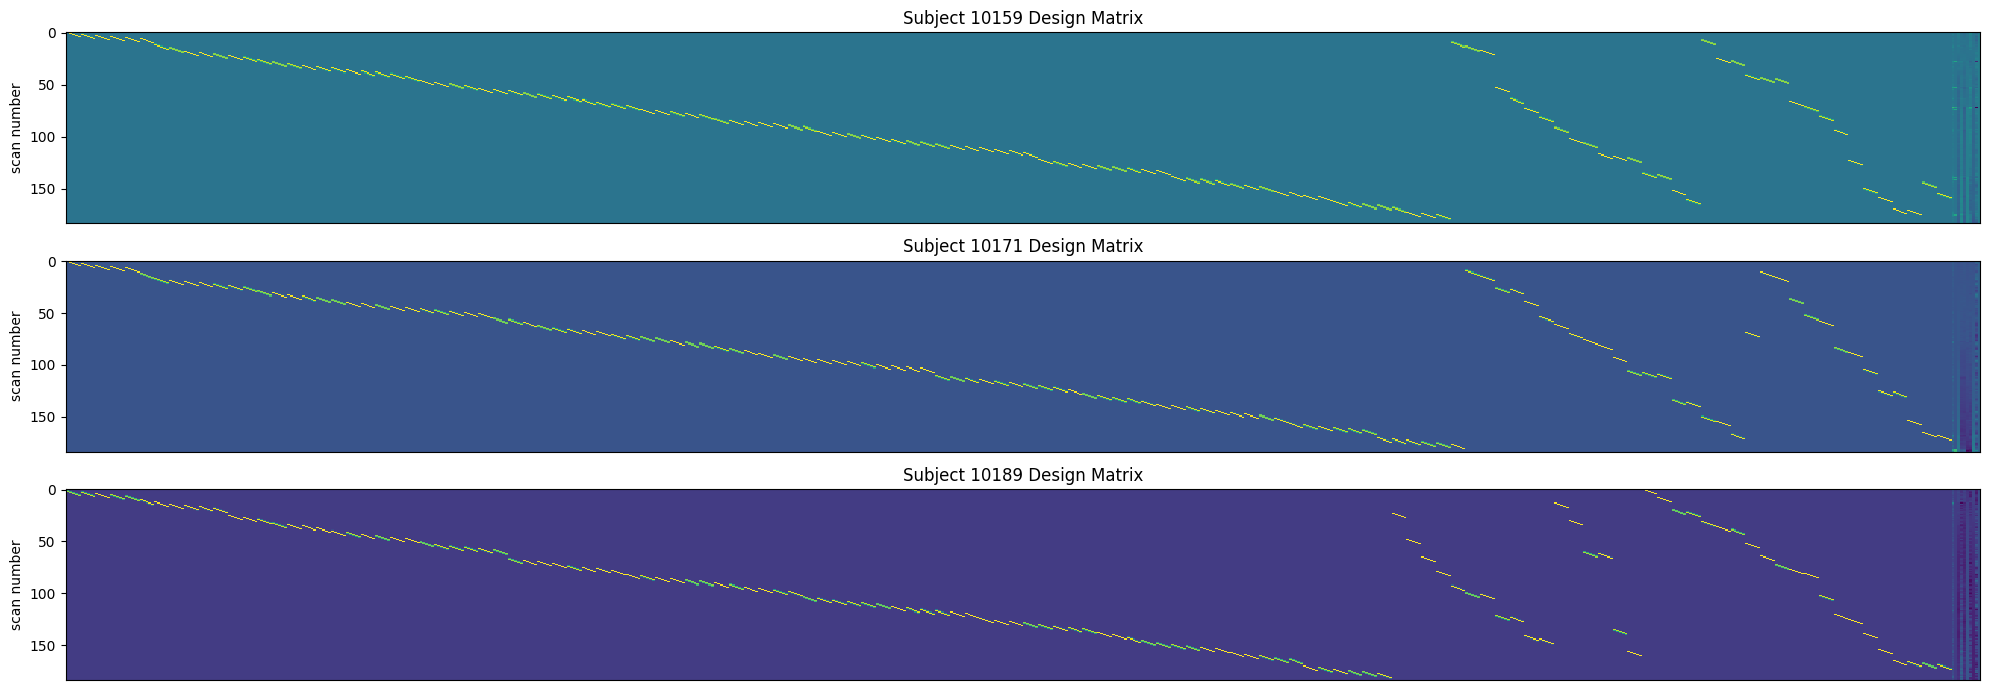

In [17]:
  # first we need to supporess superfoulous warnings
import warnings
warnings.filterwarnings("ignore", message="invalid value encountered in sqrt")
  # We suppress this becasue we are not working with z_scores from the GLM - the GLM is having issues with the background zscore calculation but we are not reguesting them - we are requesting the betas
    # These betas are not the cause of the sqrt error - that is from zscoring in the GLM. We instead zscore outside the model using a model to that does cause this issue.
    # We also just checked to make sure there were no 0 values - and there were none - indicating that we do not have to be concerned about this in our model - so we just suppress it.

fir_delays = [0, 1, 2, 3, 4]  # 5 FIR delays
n_bins = len(fir_delays)


clean_img_fir = [] # betas as is
clean_img_fir_z = [] # zscored - standardized - values after estimating fir
clean_img_fir_predicted = [] # to obtain dense continuous predicted timeseires for modeling and checking
clean_img_fir_predicted_z = [] # to zscore predicted ts
clean_img_fir_resid = [] # to obtain non-task timeseires for modeling and checking
clean_img_fir_resid_z = [] # to zscore residual ts

fig, axes = plt.subplots(len(imgs), 1, figsize=(20, 7))

for ii in range(len(imgs)):
    print(f"Subject {models[ii].subject_label}")

    ev = events[ii][["onset", "duration", "TrialOutcome"]].copy()
    ev.columns = ["onset", "duration", "trial_type"]
    ev = ev.loc[ev["trial_type"].notna()].copy()

    # Assign unique trial labels
    trial_ids = []
    trial_counter = {}
    for idx, row in ev.iterrows():
        ttype = row["trial_type"]
        trial_counter[ttype] = trial_counter.get(ttype, 0) + 1
        trial_ids.append(f"{ttype}__{trial_counter[ttype]:03d}")
    ev["trial_type"] = trial_ids

    model = nilearn.glm.first_level.FirstLevelModel(
        t_r=models[ii].t_r,
        hrf_model='fir',
        fir_delays=fir_delays,
        drift_model=None,
        high_pass=None,
        standardize=True,
        signal_scaling=False,
        minimize_memory=False,
        n_jobs=-1
    )

    model_fit = model.fit(
        imgs[ii],
        events=ev,
        confounds=confounds[ii][[
            "FramewiseDisplacement", "censor", "X", "Y", "Z",
            "RotX", "RotY", "RotZ", "WhiteMatter"
        ]]
    )

    dm = model_fit.design_matrices_[0]
    fir_cols = [c for c in dm.columns if "__" in c and "delay_" in c]

    print("   Design matrix shape:", dm.shape)
    print(f"   Number of FIR regressors: {len(fir_cols)}")

    # Build individual contrasts for each FIR regressor
    region_fir_array = []
    for fir_idx in range(len(fir_cols)):
        contrast = np.zeros(dm.shape[1])
        contrast[dm.columns.get_loc(fir_cols[fir_idx])] = 1.0

        try:
            map_img = model_fit.compute_contrast(
                contrast,
                output_type="effect_size"
            )
            region_vals = label_masker.fit_transform(map_img)  # shape: (1, n_parcels)
            region_fir_array.append(region_vals)#[0])  # remove singleton dim
        except np.linalg.LinAlgError:
            print(f"Singular matrix for {fir_cols[fir_idx]} — skipping.")
            region_fir_array.append(np.full((label_masker.fit(imgs[ii]).shape[1],), np.nan))

    region_fir_array = np.array(region_fir_array)  # shape: (n_trials * n_bins, n_nodes)
    print("   NaN parcels: ", np.isnan(region_fir_array).sum())

    # Reshape to (n_trials, n_bins, n_nodes)
    n_trials = len(ev)
    region_fir_array = region_fir_array.reshape(n_trials, n_bins, -1)
    clean_img_fir.append(region_fir_array)
    # zscore
      # zscore strategy
        # First zscore on nodes then on time inroder to preserve fir delay as is but removes trial and node scale
        # This is to ensure the GMMHMM sees well-scaled features per timepoint, but not features that destroy temporal encoding
    z_node = scipy.stats.zscore(region_fir_array, axis=2) # standardizing across nodes (axis=2) for spatial normalization
    z_time = scipy.stats.zscore(np.concatenate(z_node,axis=0), axis=0) # standardizing across time (axis=0) to stabalize temporal variance of FIR values
    z_rs = z_time.reshape(region_fir_array.shape) # reshaping to retain the (trial x delay x node) shape
    print("   zscore NaN parcels: ", np.isnan(z_rs).sum())
    clean_img_fir_z.append(z_rs)
    # predicted
    pred_ts = label_masker.fit_transform(model_fit.predicted[0])
    clean_img_fir_predicted.append(pred_ts)
    # predicted zscore
    pred_z_node = scipy.stats.zscore(pred_ts, axis=1) # standardizing across nodes (axis=1) to normalize nodes
    pred_z_time = scipy.stats.zscore(pred_z_node, axis=0) # standardizing across time (axis=0) to stabalize temporal variance of predicted timeseries
    clean_img_fir_predicted_z.append(pred_z_time)
    # residuals
    res_img = nilearn.image.math_img("a - b", a= imgs[ii], b=model_fit.predicted[0])
    res_vals = label_masker.fit_transform(res_img)
    clean_img_fir_resid.append(res_vals)
    # resid zscore
    res_z_node = scipy.stats.zscore(res_vals, axis=1) # standardizing across nodes (axis=1) to normalize nodes
    res_z_delays = scipy.stats.zscore(res_z_node, axis=0) # standardizing across time (axis=0) to stabalize temporal variance of residuals
    clean_img_fir_resid_z.append(res_z_delays)

    nilearn.plotting.plot_design_matrix(dm, axes=axes[ii])
    axes[ii].set_title(f"Subject {models[ii].subject_label} Design Matrix")
    axes[ii].tick_params(axis='x', which='both', top=False, labeltop=False)

plt.tight_layout()
plt.show()



In [18]:
(clean_img_fir[0]).shape

(128, 5, 200)

## Step 2) GMM-HMM with PCSM aligment

### Global model

In [ ]:
## Estimating Global GMMHMM model
  # Setting up values for model
    # Number of hidden states C_t
n_states = 3
    # Number of “attended‐stimulus” states X_{i,t} is an element of {0,1}
n_mixtures = 2
    # Number of fir delays
n_delays = 5
    # epislon to ensure there are not division errors (by 0) when regularizing
epsilon = 1e-6

  # GMMHMM
global_model = hmm.GMMHMM(
    n_components=n_states,
    n_mix = n_mixtures,
    covariance_type='diag',
    n_iter=100,
    verbose=False,
    random_state = 42,
      # We dont specify any initialized or learned parameters here becasue the default is to have all parameters initialize before training and update during trainining
        ## We want to learn parameters from the global model so we will use these for the subject specific model
        ## Specifically
          ### We want to fix covarainces from the global model to the individual model
          ### But we will use the other parameters as starting points
)

  # Pull all subjects data together to obtain sample level attentional states
ts_concat = np.concatenate(np.concatenate(np.array(clean_img_fir_z),axis=0),axis=0)
global_len = np.array([n_delays] * int(ts_concat.shape[0]/n_delays))

  # Fit global (all subjects) model
global_model.fit(ts_concat, lengths = global_len)

### Individual models

**NOTE**: This approach does the following:
  1) constrains variance to global model but
  2) frees individual parameters by allowing the follwoing to vary by individual:
      - means,
      - transitions,
      - start parameters,
      - and weights to individually vary
  
The advantage of this:
  1) Models individual cognitive states but grounds it in shared dynamics
  2) Variance retains a more reliable value without distorting estimates based on a single case  
  3) Interpretation is improved across individuals
      - States can be aligned to global model expectations which allows for between subject comparison more easily
      - Without this latent states have no intrinsic value and are unable to be compared across subjects

The disadvantage
  * Individual BOLD related to each state is constrained to the global model - which constrains individual level BOLD estimates for each state -
    - **HOWEVER**:
      - **This is reasonable for our current purposes** -
           1) to identify cognitive states it is important to have a reasonable expected space (based on a global model)
           2) Decoding information processing depends on the parameters that are allowed to vary individually - not the individual variance
           3) allowing individual varinace to vary procuded unrealistic values and compromises estimates
       - **This does not impact the models ability to learn cognitive states from the brain data we input into it.**
       - Individual parameters that are most relevant are allowed to vary - individulal estimates are still learned by gmmhmm


In [20]:

# Setting up values for model
  # Number of hidden attention‐states C_t
n_states = 3
  # Number of “response mixtures” states M_{i,t} is an element of {0,1}
n_mixtures = 2
  # Number of fir delays
n_delays = 5
  # epislon to ensure there are not division errors (by 0) when regularizing
epsilon = 1e-6

# Setting up lists to append to for outputs
  # Subject specific values
c_t_hat_l = []
log_lik_l = []
posterior_probs_l = []
alpha_mat_l = []
alpha_1_l = []
alpha_1_adj_l = []
trans_mat_l = []
lambda_vec_l = []
mean_mat_l = []
cov_mat_l = []
ebold_state_n = []
ebold_attn_n = []
individual_models = []

# Regularization of means and gamma (transition matrix)
    # To improve model estimation and state alignment we regularize the transition and bold intensity by state
    # Specifically - Soft regularization: blend with a weak Dirichlet-like prior for minor regulaization and numerical stability
  # Gamma transition matrix
global_reg_transmat = global_model.transmat_.copy()
global_reg_transmat = (1 - epsilon) * global_reg_transmat + epsilon * (1 / n_states)
  # Bold intensity by state
global_reg_means = global_model.means_.copy()
global_reg_means = (1 - epsilon) * global_reg_means + epsilon * (1 / n_states)

for ii in range(0,len(clean_img_fir_z)):
  # fitting individual level models updated with starting parameters from the global_model to infomr individual model fitting
  subj_model = hmm.GMMHMM(
    n_components=n_states,
    n_mix = n_mixtures,
    covariance_type='diag',
    n_iter=100,
    random_state = 42,
                      # Specifying parameters so we can learn subject-specific cognitive dynamics
    init_params = '', # We have '' so we do not initialize anything before training - this is becasue we use the global model values as starting places (If we had these here it would throw an error)
    params = 'mtsw' # here we allow individual values to be updated during training for each individual
                    ## so we learn these values from the individual subjects data
                    ## to derive subject-specific cognitive dynamics
                    ## The values we learn from each subject include:
                      #> m= means (Bold) by state and responding over time
                      #> t= transition (gamma),
                      #> s= start (lambda), and
                      #> w= weights (aka mixture weights)
                    ## The global model values are used as a prior for individual estimates
                      # these are uses as a soft regularization to stay in expected ranges
                      # We intentionally fix covarainces from the global model so that:
                        #> shorter sequences of invidual timeseries don't cause erroneous values
                        #> as individual variances are less stable
                        #> that can cause unstable estimates and infinately small log transormations
    )

    # For individual models we use the parameters learned from the global_model
      # lambda
  subj_model.startprob_ = global_model.startprob_.copy()
      # mixture weights
  subj_model.weights_ = global_model.weights_.copy()
      # covariance
  subj_model.covars_ = global_model.covars_.copy()
      # transmat (with regularized global)
  subj_model.transmat_ = global_reg_transmat
      # bold intensity by state
  subj_model.means_ = global_reg_means

  # Fit via GMMHMM to each subject individually
  subj_len = np.array([n_delays] * clean_img_fir_z[ii].shape[0])
    # Pulling each individuals data
  Y = np.concatenate(clean_img_fir_z[ii],axis = 0)
    # Fitting individual models
  subj_model.fit(Y, lengths = subj_len)
      ## aligning states
  subj_model, order = alg.align_model_to_expected(subj_model, global_model, wt_var=True)
    # saving individual model parameters
  c_t_hat = subj_model.predict(Y, lengths = subj_len)
  log_lik, posterior_probs = subj_model.score_samples(Y, lengths = subj_len)
  alpha_mat = np.column_stack(
      (
          subj_model.weights_[:,1], 1 - subj_model.weights_[:,1]
          )
      )
  alpha_1 = subj_model.weights_[:,1]
  alpha_1_adj = subj_model.weights_ @ subj_model.weights_.mean(axis=0) # adjusting alpha by probability of responding to either stimuli
  trans_mat = subj_model.transmat_
  lambda_vec = subj_model.startprob_
  mean_mat = subj_model.means_                # Note this will be the same for all subjects because we use the global model values to fix this across subjects
  cov_mat = subj_model.covars_
  expected_bold_state_by_node = (subj_model.means_ * subj_model.weights_[:,:,None]).mean(axis=1)  #(latent state, nodes)
  expected_bold_respond_by_node = (subj_model.means_ * subj_model.weights_[:,:,None]).mean(axis=0) #(respond, nodes)
    # appending values to lists
  c_t_hat_l.append(c_t_hat)
  log_lik_l.append(log_lik)
  posterior_probs_l.append(posterior_probs)
  alpha_mat_l.append(alpha_mat)
  alpha_1_l.append(alpha_1)
  alpha_1_adj_l.append(alpha_1_adj)
  trans_mat_l.append(trans_mat)
  lambda_vec_l.append(lambda_vec)
  mean_mat_l.append(mean_mat)
  cov_mat_l.append(cov_mat)
  ebold_state_n.append(expected_bold_state_by_node)
  ebold_attn_n.append(expected_bold_respond_by_node)
  individual_models.append(subj_model)


#### Checking Transition Matricies and Entropy
- Transitions are expected to be higher in the diagonal for some states for at least some participants
  * if ~0.3-0.4 it indicates a less clear state presence and difficulty transitioning.
- Entropy should correspond to the transition matrix (higher diagonal = lower entropy, lower diagonal = higher entropy)

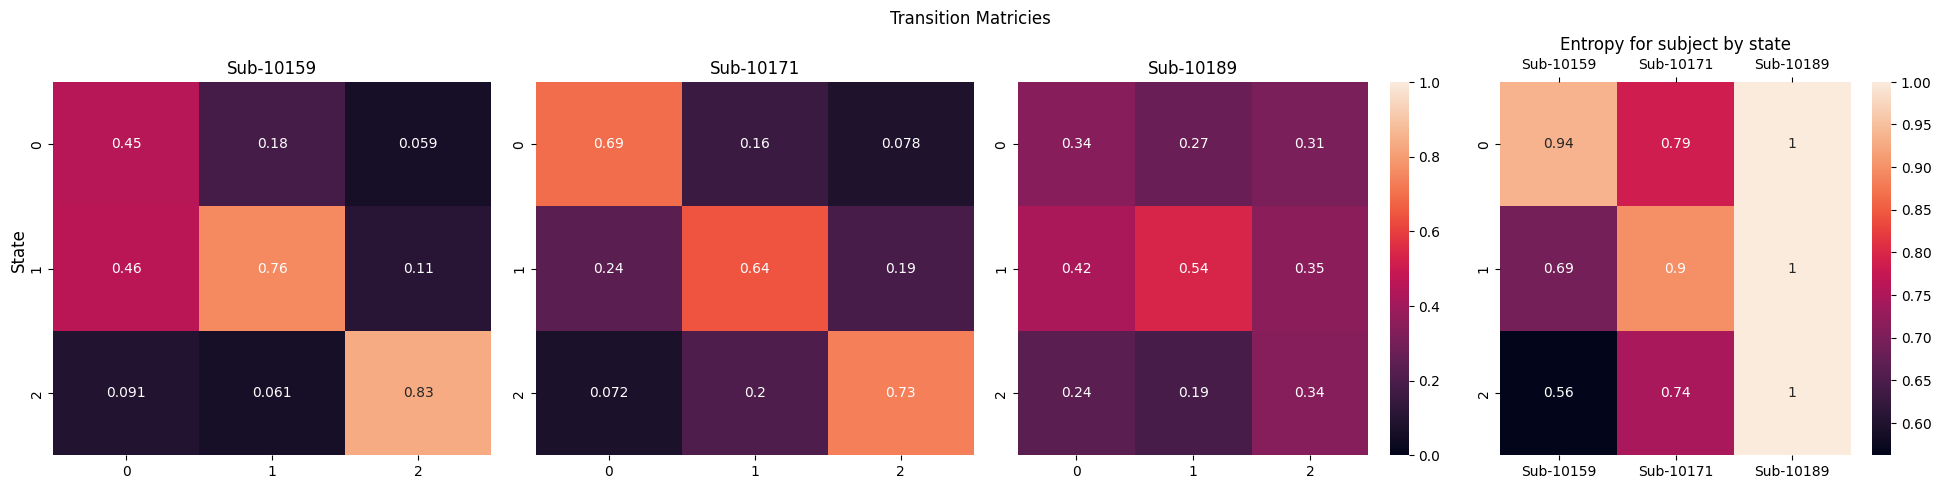

In [80]:
import seaborn as sns
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ii in range(len(trans_mat_l)):
  if ii < 2:
    sns.heatmap(trans_mat_l[ii].T, annot=True, vmin=0,vmax=1, cbar=None,ax=axes[ii])
    axes[ii].set_title(f"Sub-{models[ii].subject_label}")
  else:
    sns.heatmap(trans_mat_l[ii].T, annot=True, vmin=0,vmax=1,ax=axes[ii])
    axes[ii].set_title(f"Sub-{models[ii].subject_label}")
  fig.suptitle("Transition Matricies")
  fig.supylabel("State")
  fig.tight_layout(pad=1.5)


## This indicates level of randomness for each latent state
  # Higher values suggest more difficulty/energy loss when transitioning to that state
  # We expect that
    # - lower values correspond to higher transition diagonal values by state
    # - higher values correspond to lower transiotion diagonal values by state

se = []
for ii in range(len(trans_mat_l)):
  G = trans_mat_l[ii]
  from scipy.stats import entropy
  state_entropy = [round(entropy(row),3) for row in G]
  se.append(pd.DataFrame(state_entropy, columns = [f"Sub-{models[ii].subject_label}"]))
se2 = pd.concat(se, axis=1).clip(0,1)


sns.heatmap(se2, annot=True, vmin=np.min(se2),vmax=np.max(se2),ax=axes[3])
plt.title("Entropy for subject by state")
plt.tick_params(top=True, labeltop=True, bottom=True, labelbottom=True)
plt.show()
plt.close()

This figures shows that the first two subjects have more reliable state occupancy; However, the third subject has a less clear state occupancy suggesting a greater rate of transitions between latent states.

These transition matricies correspond to the entropy matrix on the right where the diagonals wiht higher values correspond to lower entropy (e.g., see sub-10159 state 2 transition and state 2 entropy) and lower diagonals have higher entropy (see sub-10189 all states).

## Step 3) PCSM Emergent Decoding

## PCSM Diagnostics

### Calculating Temporal Stability $\rho_t$

In [22]:
rho_l = []
for ii in posterior_probs_l:
  rho_l.append(mc.compute_rho(ii))

len(rho_l) == 3

True

### Calculating Brain Response Probabilty $P_t$

In [23]:
pt_l = []
for ii in range(len(posterior_probs_l)):
  pt_l.append(mc.compute_pt(posterior_probs_l[ii], alpha_1_l[ii]))

len(pt_l) == 3

True

### Calculating Model-Data Distance Discrepancy $D^{Maha}_t$

In [24]:
dmaha_l = []
for ii in range(len(posterior_probs_l)):
  dmaha_l.append(mc.compute_D_maha_fir_mahalanobis(posterior_probs_l[ii], mean_mat_l[ii], clean_img_fir_z[ii]))

len(dmaha_l) == 3

True

### Flagging Timepoints and Trials

Using $D^{Maha}_t$ to identify timepoints for further investigation with $\rho_t$ and $P_t$ - timepoints and trials are flagged.

Given that large flucturations for one timepoint are very likely and indicate a suddend change - these flagged tiempoint are not as concerning for PCSM decoding.

However if at least 50% of timepoints in a trial are flagged - this is cause for concern and considreation for removel

In [25]:
flag_time_l = []
flag_trial_l = []
for ii in range(len(posterior_probs_l)):
  time, trial = mc.flag_trials(dmaha_l[ii], rho_l[ii], pt_l[ii])[0:2]
  flag_time_l.append(time)
  flag_trial_l.append(trial)

len(flag_time_l) == 3

True

In [26]:
for ii in range(len(flag_time_l)):
  print(f"Subject {models[ii].subject_label}",
        f"\n  flagged timepoints - \n     n: {len(flag_time_l[ii])}, \n     %: {len(flag_time_l[ii])/(128*5)}",
        f"\n  flagged trials - \n     n: {len(flag_trial_l[ii])}, \n     %: {len(flag_trial_l[ii])/(128)}")

Subject 10159 
  flagged timepoints - 
     n: 0, 
     %: 0.0 
  flagged trials - 
     n: 0, 
     %: 0.0
Subject 10171 
  flagged timepoints - 
     n: 50, 
     %: 0.078125 
  flagged trials - 
     n: 0, 
     %: 0.0
Subject 10189 
  flagged timepoints - 
     n: 129, 
     %: 0.2015625 
  flagged trials - 
     n: 0, 
     %: 0.0


#### **No evidence to remove any trials or timepoints**

These descriptive suggest that there is low evidence that quality will impact subsequent decoding given that time flags are not affecting trials and only a small proportion of timepoints are affected.

Also subjest 10189 that had a less clear transition matrix had the most flagged timepoints - which was expected. Given that this is indicative of a less stable state for that participant it is also expectd that this subject would have strong flucturations that do not necessarily impact whole trials. This data is still usable for the emergent decoding steps.

## PCSM Emergent Decoding: **Node response and Serial/Parallel Decoding**

### Computing BOLD Response by Node $B^{node}_{t,n}$

In [27]:
bnode_l = []
for ii in range(len(posterior_probs_l)):
  bnode_l.append(mc.compute_B_node(posterior_probs_l[ii], mean_mat_l[ii], clean_img_fir_z[ii])[0])

len(bnode_l) == 3

True

### Computing Deviation in Node Response for Serial/Parallel Processing $D^{SP}_t$

In [28]:
dsp_l = []
dsp_if_l = []
for ii in range(len(posterior_probs_l)):
  dsp_v, dsp_info = mc.compute_Dsp(bnode_l[ii], verbose=True)
  dsp_l.append(dsp_v)
  dsp_if_l.append(dsp_info)

len(dsp_l) == 3

True

In [31]:
dsp_tp_desc = []
sub_indx = []
for ii in range(len(dsp_if_l)):
  dsp_tp_desc.append(dsp_if_l[ii]["n_timepoints"])
  sub_indx.append(models[ii].subject_label)

pd.DataFrame(dsp_tp_desc, index=sub_indx)

,serial_n_timepoints,mixed_n_timepoints,parallel_n_timepoints
10159,257,74,309
10171,471,40,129
10189,446,51,143


The outputs show that subject 10159 had the most timepoints in parallel while 10171 had the least, and 10189 was betweeen these two. Lets look at the plots


 SUB- 10159 



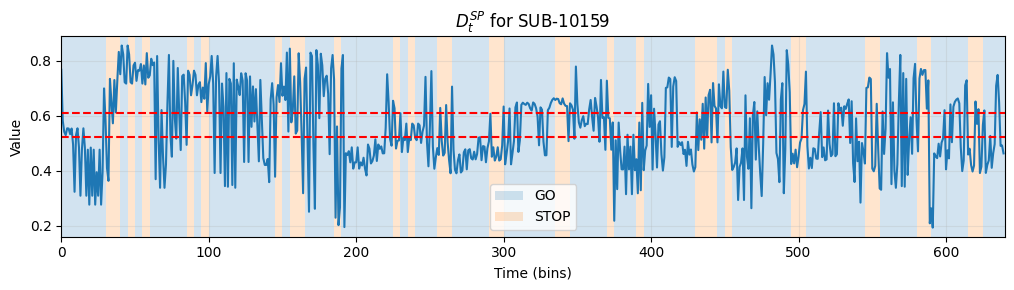

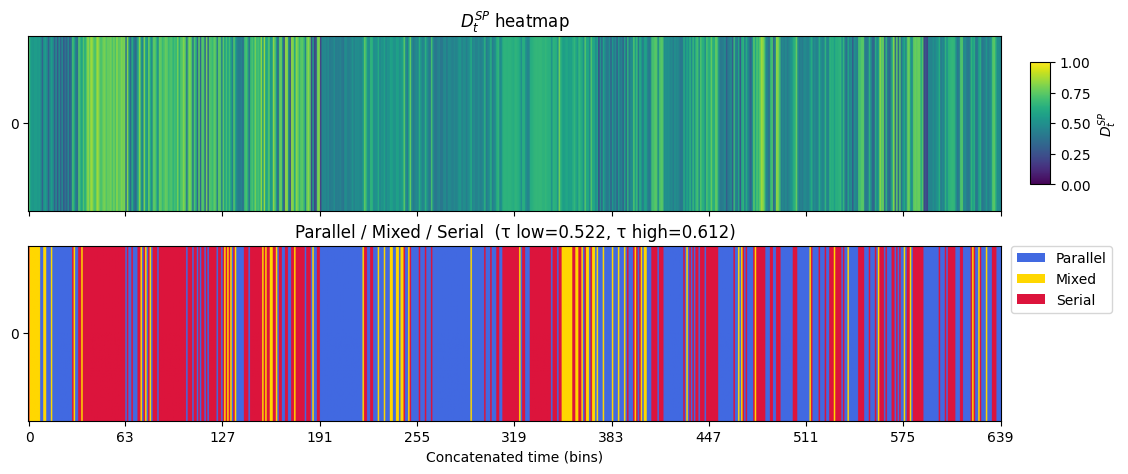


 SUB- 10171 



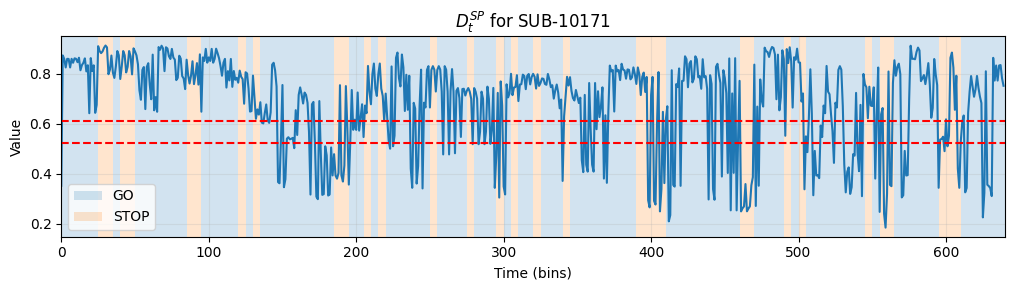

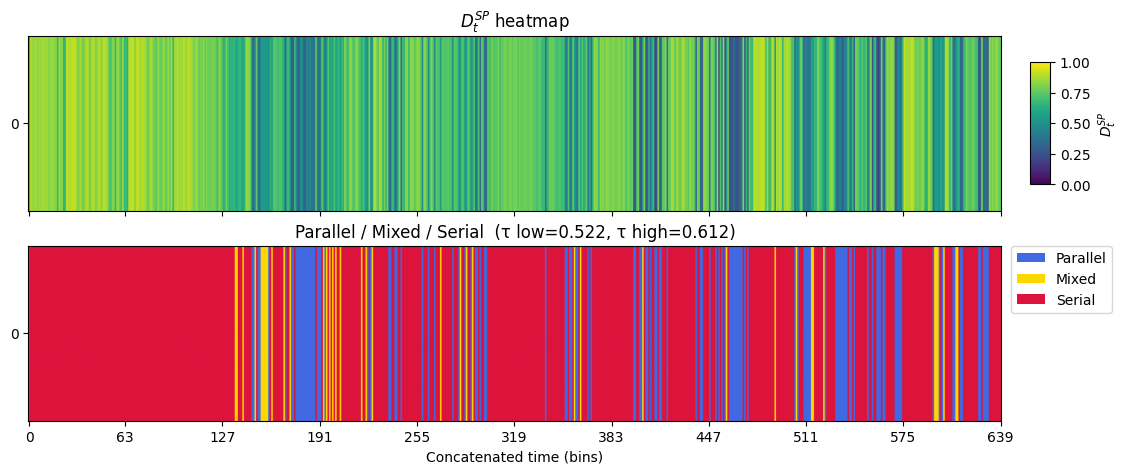


 SUB- 10189 



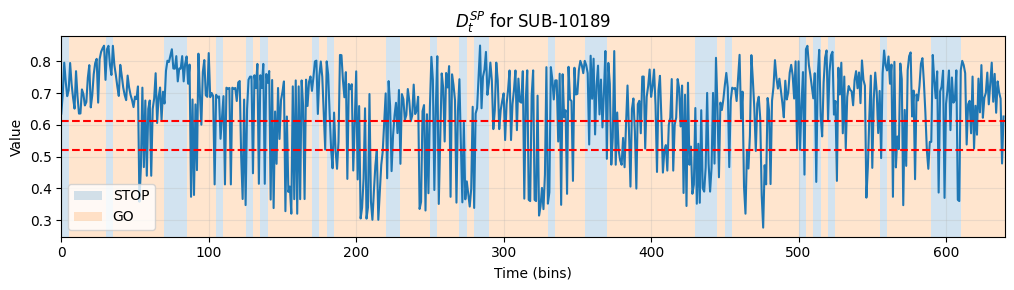

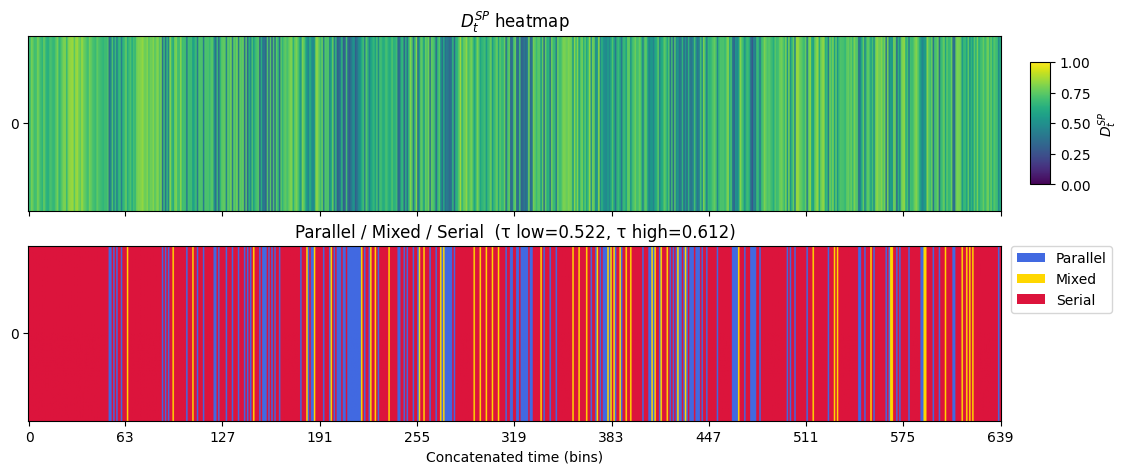

In [30]:
for ii in range(len(dsp_l)):
  print("\n SUB-", sub_indx[ii],"\n")
  valid_events = events[ii][events[ii]["TrialOutcome"].notna()].copy()
  pj_plt.plot_timeseries_with_trials(
      series=dsp_l[ii],
      trial_labels=valid_events["trial_type"],
      include_line_labels=False,
      figsize=(10.25,3),
      title = r"$D^{SP}_t$ for " f"SUB-{sub_indx[ii]}",
      hlines=[0.522,0.612],
      hline_kwargs={'color': 'red', 'linestyle': '--', 'linewidth': 1.5})
  pj_plt.plot_dsp_timeseries_heatmaps(dsp_l[ii])


## PCSM Emergent Decoding: **Demand and Resources**

### Computing Instataneous Cognitive Load Demand $L^{demand}_t$ and Recources $R^{level}_t$

In [88]:
demand_l = []
demand_norm_l = []
resource_l = []
mode_labels_l = []
for ii in range(len(posterior_probs_l)):
  # print("\n SUB-", sub_indx[ii],"\n")
  demand, resource_level, impact, impact_severity, demand_info, resource_info, components = mc.compute_transition_load(posterior_probs_l[ii], dsp_l[ii])
  demand_l.append(demand)
  resource_l.append(resource_level)
  mode_labels_l.append(components["labels"]["mode"])
  demand_norm_l.append(components["flows"]["demand_bounded"])

len(demand_l) == 3

True

#### Plotting Subject Specific Demand


 SUB- 10159 



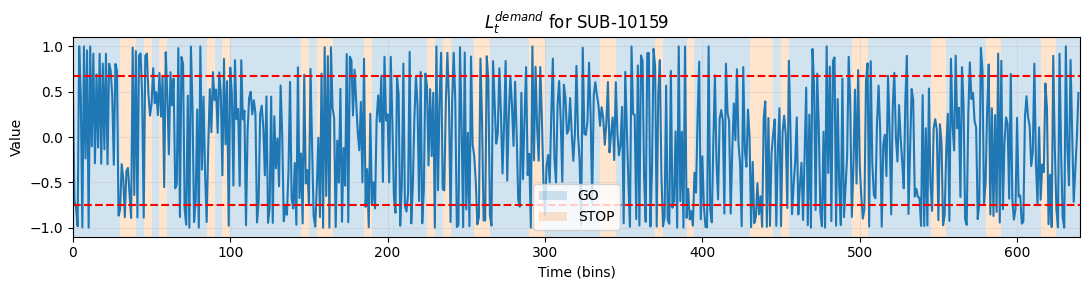


 SUB- 10171 



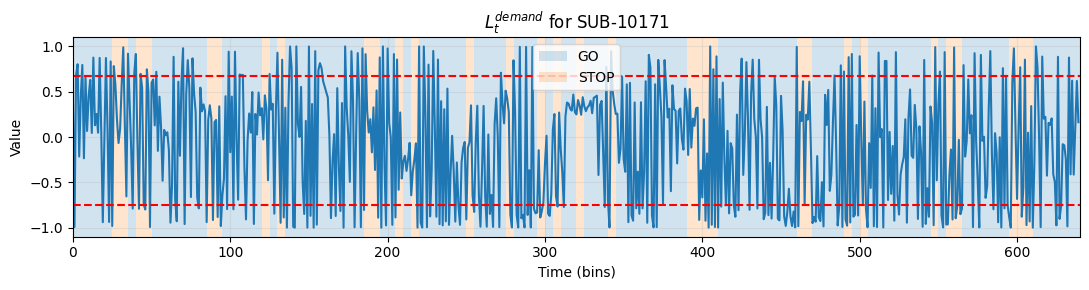


 SUB- 10189 



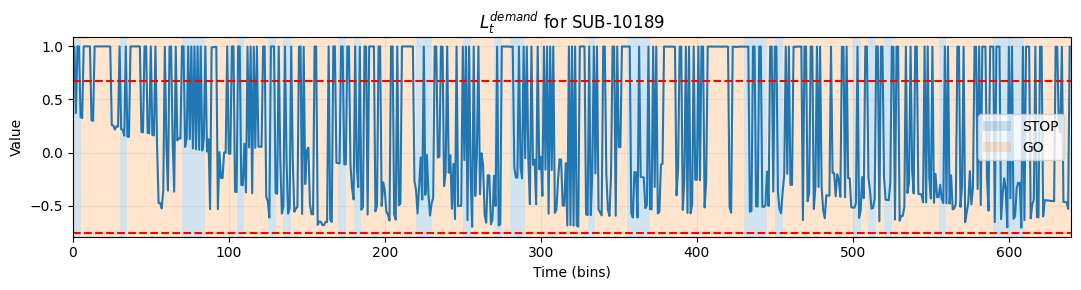

In [63]:
for ii in range(len(dsp_l)):
  print("\n SUB-", sub_indx[ii],"\n")
  valid_events = events[ii][events[ii]["TrialOutcome"].notna()].copy()
  pj_plt.plot_timeseries_with_trials(
      series=demand_norm_l[ii],
      trial_labels=valid_events["trial_type"],
      include_line_labels=False,
      figsize=(11,3),
      title = r"$L^{demand}_t$ for " f"SUB-{sub_indx[ii]}",
      hlines=[-0.7499,0.6752],
      hline_kwargs={'color': 'red', 'linestyle': '--', 'linewidth': 1.5})

#### Plotting Subject Specific Resources


 SUB- 10159 



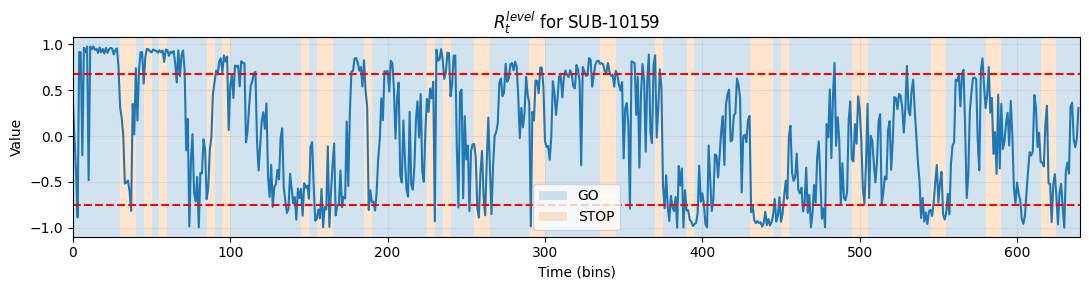


 SUB- 10171 



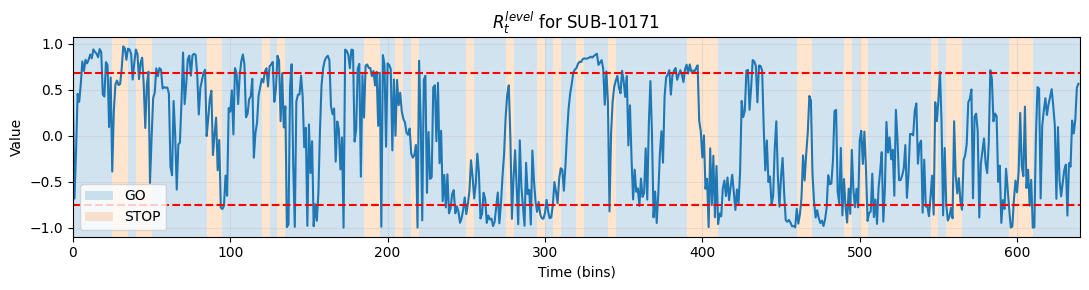


 SUB- 10189 



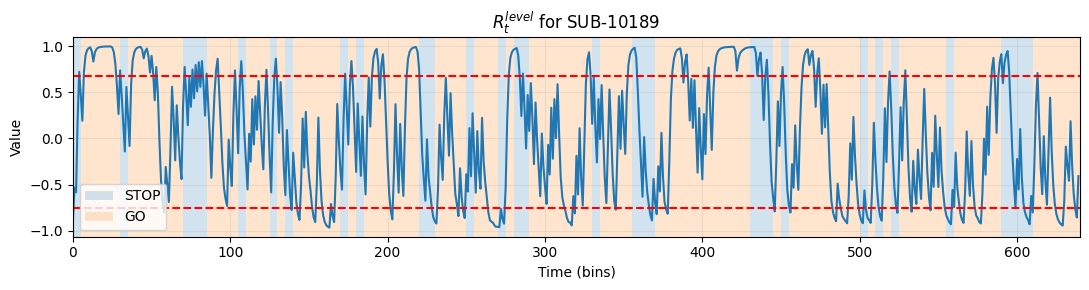

In [40]:
for ii in range(len(dsp_l)):
  print("\n SUB-", sub_indx[ii],"\n")
  valid_events = events[ii][events[ii]["TrialOutcome"].notna()].copy()
  pj_plt.plot_timeseries_with_trials(
      series=resource_l[ii],
      trial_labels=valid_events["trial_type"],
      include_line_labels=False,
      figsize=(11,3),
      title = r"$R^{level}_t$ for " f"SUB-{sub_indx[ii]}",
      hlines=[-0.7499,0.6752],
      hline_kwargs={'color': 'red', 'linestyle': '--', 'linewidth': 1.5})

## PCSM Emergent Decoding: **Serial Bottleneck**

Taking the demand and serial/parallel decoding labels, we can now examine the overal persistance in serial bottleneck in the following function.

Values > ~0 are considered a long bottleneck

In [68]:
serial_bottleneck_l = []
for ii in range(len(posterior_probs_l)):
  serial_bottleneck_l.append(mc.compute_serial_bottleneck(mode_labels_l[ii], demand_l[ii], verbose=False))

In [69]:
for ii in range(len(serial_bottleneck_l)):
  print("\n SUB-", sub_indx[ii], f": {serial_bottleneck_l[ii]}")


 SUB- 10159 : -0.5804730952358822

 SUB- 10171 : -0.5352347285207535

 SUB- 10189 : -0.5698248681918802


None of these subjects had a long bottleneck but these values reprsent a magnituded that can be compared between subjects or assocaited with a varialble of interst to test the relationshi between the severity of a serial bottleneck and a phenomena of interest.  

# Next Steps / Summary
With these values extracted, any number of scientific questions can be answered such as mental health symptom associations or categorical comparisions, PCSM metric assocaitions with task performance, interactions across these, or can be adapted to an area or topic of interest where cognitive properteis of processing, load/demand, and serial bottlenecks are relevant.

### Software Versions

In [90]:
%load_ext watermark
%watermark -n -u -v -iv -w

The watermark extension is already loaded. To reload it, use:
  %reload_ext watermark
Last updated: Sun Nov 02 2025

Python implementation: CPython
Python version       : 3.12.12
IPython version      : 7.34.0

IPython   : 7.34.0
matplotlib: 3.10.0
sklearn   : 1.6.1
numpy     : 2.0.2
nibabel   : 5.3.2
pandas    : 2.2.2
watermark : 2.5.0
sys       : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
nilearn   : 0.12.1
scipy     : 1.16.3
hmmlearn  : 0.3.3
projlib   : 0.1.0
seaborn   : 0.13.2

Watermark: 2.5.0

